In [ ]:
import pandas as ps
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Cargar dataset
ps.read_csv('diabetes.csv')

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# Colcar nombres de las columnas
nombres_columnas = ['Embarazos', 'Glucosa', 'PresionArterial', 'GrosorPiel', 'Insulina',
           'IMC', 'FuncionPedigreeDiabetes', 'Edad', 'Resultados']

df = ps.read_csv('diabetes.csv', header=None, names=nombres_columnas)
df.head()

,Embarazos,Glucosa,PresionArterial,GrosorPiel,Insulina,IMC,FuncionPedigreeDiabetes,Edad,Resultados
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Embarazos                768 non-null    int64  
 1   Glucosa                  768 non-null    int64  
 2   PresionArterial          768 non-null    int64  
 3   GrosorPiel               768 non-null    int64  
 4   Insulina                 768 non-null    int64  
 5   IMC                      768 non-null    float64
 6   FuncionPedigreeDiabetes  768 non-null    float64
 7   Edad                     768 non-null    int64  
 8   Resultados               768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Tablas interactivas
!pip install google-colab
!pip install pandas-datatable

from google.colab import data_table

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pandas-datatable (from versions: none)
ERROR: No matching distribution found for pandas-datatable


In [ ]:
#Tabla interactiva
data_table.enable_dataframe_formatter()
df

,Embarazos,Glucosa,PresionArterial,GrosorPiel,Insulina,IMC,FuncionPedigreeDiabetes,Edad,Resultados
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
columnas_con_ceros = ['Glucosa', 'PresionArterial', 'GrosorPiel', 'Insulina', 'IMC']
df[columnas_con_ceros]=df[columnas_con_ceros].replace(0, np.nan)
df_limpio = df.dropna()
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Embarazos                392 non-null    int64  
 1   Glucosa                  392 non-null    float64
 2   PresionArterial          392 non-null    float64
 3   GrosorPiel               392 non-null    float64
 4   Insulina                 392 non-null    float64
 5   IMC                      392 non-null    float64
 6   FuncionPedigreeDiabetes  392 non-null    float64
 7   Edad                     392 non-null    int64  
 8   Resultados               392 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 30.6 KB


In [ ]:
# Agregar una nueva columna para las edades
def categorizar_edad(edad):
    if edad < 30:
        return "Joven menor de 30 años"
    elif 30 <= edad < 50:
        return "Adulto entre 30 y 50 años"
    else:
        return "Adulto mayor de 50 años"

df_limpio['Grupo_Edad']=df_limpio['Edad'].apply(categorizar_edad)
df_limpio

,Embarazos,Glucosa,PresionArterial,GrosorPiel,Insulina,IMC,FuncionPedigreeDiabetes,Edad,Resultados,Grupo_Edad
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Joven menor de 30 años
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Adulto entre 30 y 50 años
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,Joven menor de 30 años
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,Adulto mayor de 50 años
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1,Adulto mayor de 50 años
...,...,...,...,...,...,...,...,...,...,...
753,0,181.0,88.0,44.0,510.0,43.3,0.222,26,1,Joven menor de 30 años
755,1,128.0,88.0,39.0,110.0,36.5,1.057,37,1,Adulto entre 30 y 50 años
760,2,88.0,58.0,26.0,16.0,28.4,0.766,22,0,Joven menor de 30 años
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,Adulto mayor de 50 años


In [ ]:
from enum import auto
def visualizacion_datos(df):
  fig, axs = plt.subplots(2, 3, figsize=(20, 20))
  fig.suptitle('Análisis visual del Dataset de Diabetes', fontsize=20)

  # Grafico de lineas Edad vs Glucosa
  df.groupby('Edad')['Glucosa'].mean().plot(
      kind='line',
      ax=axs[0, 0],
      marker='.'
    )
  axs[0, 0].set_title('Nivel de Glucosa del paciente por grupo de edad')
  axs[0, 0].set_xlabel('Grupo de Edad')
  axs[0, 0].set_ylabel('Nivel de Glucosa')

  # Grafico de barras Total de personas vs Grupo de edad
  df.groupby('Grupo_Edad').count()['Edad'].plot(
      kind='bar',
      ax=axs[0, 1],
      color=['blue', 'green', 'red']
    )
  axs[0, 1].set_title('Total de personas por grupo de edad')
  axs[0, 1].set_xlabel('Grupo de Edad')
  axs[0, 1].set_ylabel('No.Personas')

  # Histograma (1, 0)
  axs[1, 0].hist(df['IMC'], bins=20, color='purple', alpha=0.5)
  axs[1, 0].set_title('Histograma IMC')
  axs[1, 0].set_xlabel('IMC')
  axs[1, 0].set_ylabel('Frecuencia')

  #Boxplot
  datos_boxplot = [df[df['Resultados'] == 0]['Edad'], df[df['Resultados'] == 1]['Edad']]
  axs[1, 1].boxplot(datos_boxplot,
                    labels=['No Diabetico', 'Diabetico'])
  axs[1, 1].set_title('Distribucion de la edad por resultado de diabetes (0=No Diabetico, 1=Diabetico)')
  axs[1, 1].set_xlabel('Resultados')

  # Grafico de pastel (Pie) porcentaje de resultados No Diabetico (0) o Diabetico (1)
  conteo_resultados = df['Resultados'].value_counts()
  conteo_resultados.plot(
      kind='pie',
      ax=axs[1, 2],
      labels=['No Diabetico (0)', 'Diabetico (1)'],
      autopct='%1.1f%%', # Porcentaje con un decimal
      colors=['green', 'red']
    )
  axs[1, 2].set_title('Porcentaje de resultados (0=No Diabetico, 1=Diabetico)')

  #Scatter Glucosa vs IMC
  colores = df['Resultados'].map({0: 'blue', 1: 'red'})
  axs[0, 2].scatter(df['Glucosa'], df['IMC'], c=colores, alpha=0.5)
  axs[0, 2].set_title('Dispersion: Glucosa vs IMC')
  axs[0, 2].set_xlabel('Glucosa')
  axs[0, 2].set_ylabel('IMC')
  # Colocar las leyendas
  leyendas_elementos = [
      mpatches.Patch(color='blue', label='No Diabetico (0)'),
      mpatches.Patch(color='red', label='Diabetico (1)')
  ]
  axs[0, 2].legend(handles=leyendas_elementos)

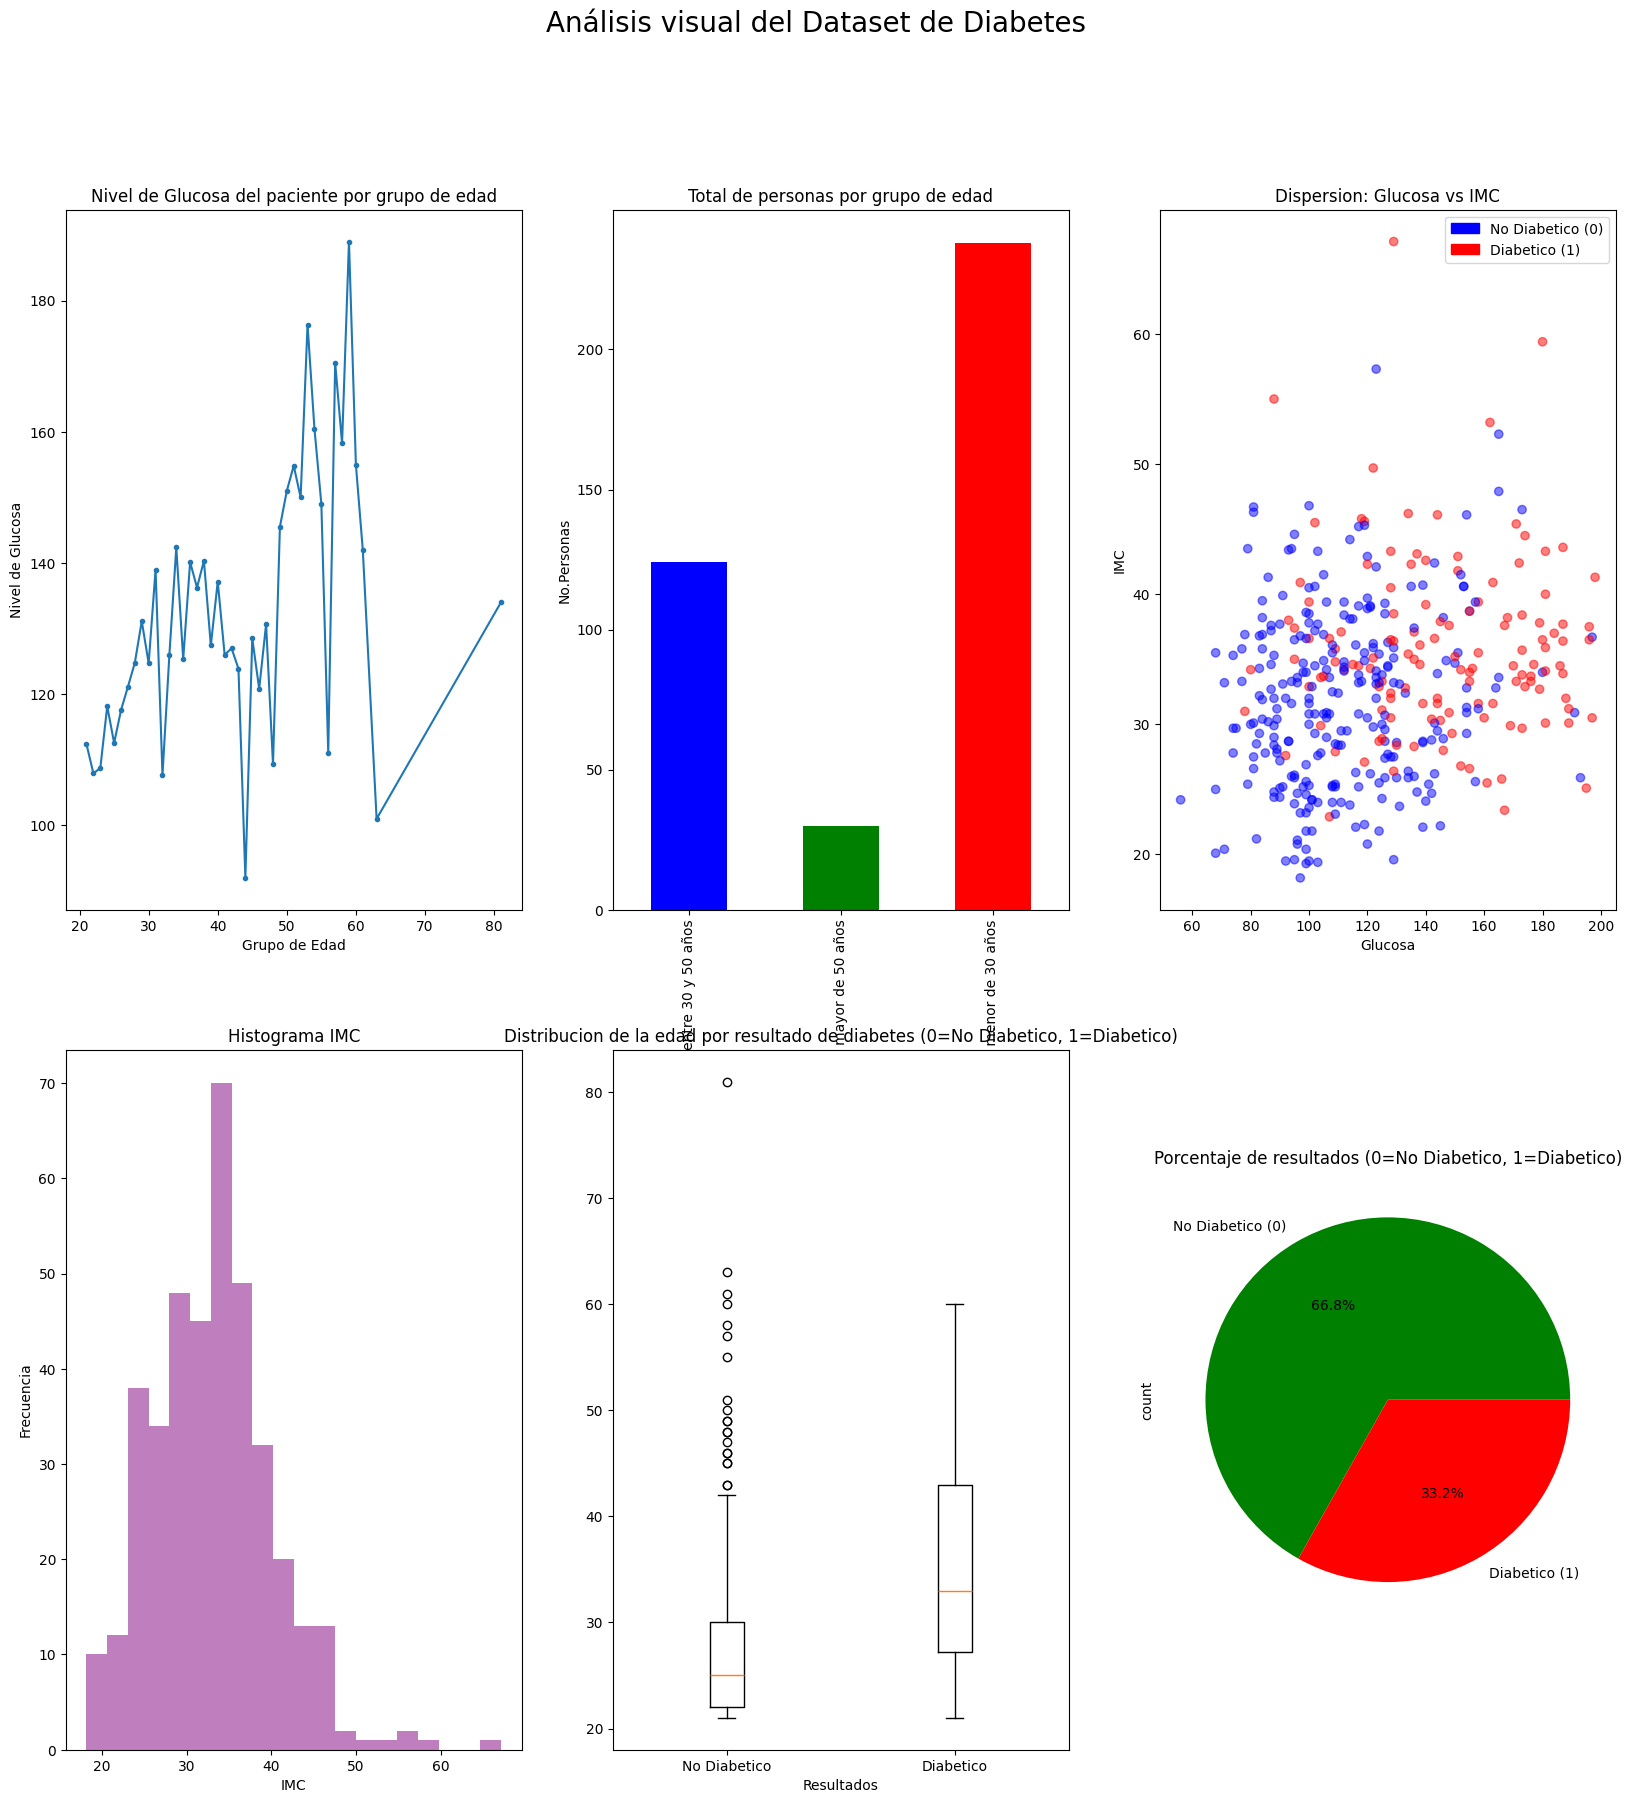

In [ ]:
visualizacion_datos(df_limpio)

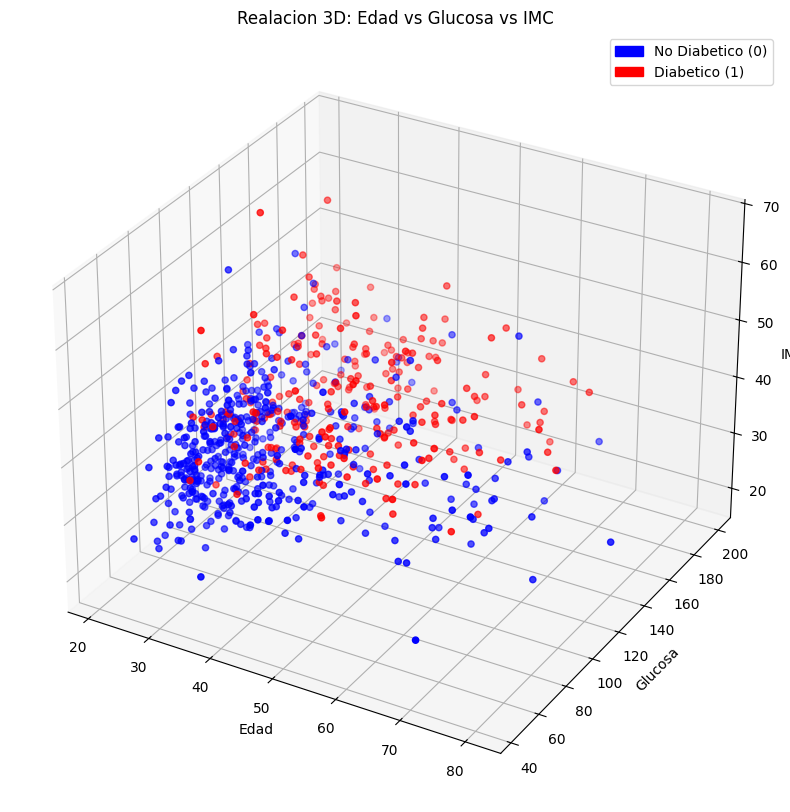

In [ ]:
# Graficas 3D
fig_3d = plt.figure(figsize=(10, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Datos: Edad, Glucosa, IMC
colores = df['Resultados'].map({0: 'blue', 1: 'red'})
ax_3d.scatter(df['Edad'], df['Glucosa'], df['IMC'],
              c=colores,
              marker = 'o')

#Titulos
ax_3d.set_title('Realacion 3D: Edad vs Glucosa vs IMC')
ax_3d.set_xlabel('Edad')
ax_3d.set_ylabel('Glucosa')
ax_3d.set_zlabel('IMC')

# Colocar las leyendas
leyendas_elementos = [
    mpatches.Patch(color='blue', label='No Diabetico (0)'),
    mpatches.Patch(color='red', label='Diabetico (1)')
]
plt.legend(handles=leyendas_elementos)
plt.show()